# Rtau Sweep Data Loading and Analysis

This notebook loads the `.npz` files written by `main_local.py`, checks which saved fields are present, plots the calculated `Rtau_scar` physics, averages over disorder seeds, and tracks how recorded calculation time scales with system size.

In [51]:
# Setup and current sweep configuration
from pathlib import Path
import contextlib
import importlib
import io
import re
import sys
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import pandas as pd
except ImportError:
    pd = None

NOTEBOOK_DIR = Path.cwd()
FALLBACK_DIR = Path("/Users/shemian29/Library/CloudStorage/Dropbox/UIC/Research/QuantumBatteries/Idden_code")

if not (NOTEBOOK_DIR / "Data").exists() and (FALLBACK_DIR / "Data").exists():
    NOTEBOOK_DIR = FALLBACK_DIR

DATA_DIR = NOTEBOOK_DIR / "Data"
SCRIPT_DIR = NOTEBOOK_DIR

if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

with contextlib.redirect_stdout(io.StringIO()):
    import main_local
    main_local = importlib.reload(main_local)

EXPECTED_NLIST = [int(system_size) for system_size in main_local.nlist]
EXPECTED_REALS = int(main_local.reals)
EXPECTED_PARAMETER_POINTS_PER_N = len(main_local.xlist) * len(main_local.ylist) * len(main_local.zlist) * len(main_local.dslist) * len(main_local.ddlist)
EXPECTED_FILES_PER_N = EXPECTED_PARAMETER_POINTS_PER_N * EXPECTED_REALS
EXPECTED_TOTAL_FILES = len(main_local.parameter_sweep) * EXPECTED_REALS

SWEEP_CONFIG = {
    "DATA_DIR": DATA_DIR,
    "N values": EXPECTED_NLIST,
    "realizations per parameter point": EXPECTED_REALS,
    "parameter points per N": EXPECTED_PARAMETER_POINTS_PER_N,
    "expected files per N": EXPECTED_FILES_PER_N,
    "expected total files": EXPECTED_TOTAL_FILES,
}

SWEEP_CONFIG

{'DATA_DIR': PosixPath('/Users/shemian29/Library/CloudStorage/Dropbox/UIC/Research/QuantumBatteries/Idden_code/Data'),
 'N values': [4, 6, 8],
 'realizations per parameter point': 50,
 'parameter points per N': 108,
 'expected files per N': 5400,
 'expected total files': 16200}

In [52]:
# Filename parsing and file loading helpers
FILENAME_PATTERN = re.compile(
    r"^Rtau_N(?P<N>\d+)"
    r"_x(?P<x>[-+0-9p]+)"
    r"_y(?P<y>[-+0-9p]+)"
    r"_z(?P<z>[-+0-9p]+)"
    r"_ds(?P<ds>[-+0-9p]+)"
    r"_dd(?P<dd>[-+0-9p]+)"
    r"_seed(?P<seed>\d+)"
    r"_tmax(?P<t_max>[-+0-9.eE]+)\.npz$"
)

PARAMETER_COLUMNS = ["N", "x", "y", "z", "ds", "dd", "seed", "t_max"]
NON_SEED_PARAMETERS = ["N", "x", "y", "z", "ds", "dd"]
SORT_COLUMNS = ["N", "x", "y", "z", "ds", "dd", "seed"]


def p_token_to_float(token: str) -> float:
    return float(token.replace("p", "."))


def np_scalar(value: np.ndarray):
    return value.item() if np.shape(value) == () else value


def parse_result_filename(path: Path) -> dict:
    match = FILENAME_PATTERN.match(path.name)
    if match is None:
        raise ValueError(f"Unexpected result filename: {path.name}")

    parts = match.groupdict()
    return {
        "N": int(parts["N"]),
        "x": p_token_to_float(parts["x"]),
        "y": p_token_to_float(parts["y"]),
        "z": p_token_to_float(parts["z"]),
        "ds": p_token_to_float(parts["ds"]),
        "dd": p_token_to_float(parts["dd"]),
        "seed": int(parts["seed"]),
        "t_max": float(parts["t_max"]),
    }


def load_result(path: Path) -> dict:
    path = Path(path)
    with np.load(path, allow_pickle=False) as data:
        result = {key: np_scalar(data[key]) for key in data.files}

    result["path"] = path
    result["filename"] = path.name
    return result


def values_match(actual, expected, atol: float = 1e-12) -> bool:
    if isinstance(actual, float) or isinstance(expected, float):
        return np.isclose(actual, expected, atol=atol, rtol=0.0)
    return actual == expected


def filter_catalog(rows: list[dict], **filters) -> list[dict]:
    selected = []

    for row in rows:
        if all(values_match(row[key], value) for key, value in filters.items()):
            selected.append(row)

    return selected


def to_table(rows: list[dict], sort_columns: list[str] | None = None):
    if pd is None:
        if sort_columns is None:
            return rows
        return sorted(rows, key=lambda row: tuple(row[column] for column in sort_columns if column in row))

    table = pd.DataFrame(rows)
    if table.empty or sort_columns is None:
        return table

    usable_sort_columns = [column for column in sort_columns if column in table.columns]
    return table.sort_values(usable_sort_columns).reset_index(drop=True)

In [53]:
# Discover result files

def discover_results(data_dir: Path = DATA_DIR) -> list[dict]:
    data_dir = Path(data_dir)
    rows = []

    for path in sorted(data_dir.glob("Rtau_*.npz")):
        row = parse_result_filename(path)
        row["path"] = path
        row["filename"] = path.name
        rows.append(row)

    return rows


catalog = discover_results()
catalog_table = to_table(catalog, SORT_COLUMNS)

print(f"Found {len(catalog)} result files in {DATA_DIR}")
print(f"Expected total files for current script configuration: {EXPECTED_TOTAL_FILES}")

if pd is None:
    display(catalog_table[:20])
else:
    display(catalog_table.head(20))

Found 40 result files in /Users/shemian29/Library/CloudStorage/Dropbox/UIC/Research/QuantumBatteries/Idden_code/Data
Expected total files for current script configuration: 16200


,N,x,y,z,ds,dd,seed,t_max,path,filename
0,4,0.001,0.001,0.001,0.1,0.01,0,157.079633,/Users/shemian29/Library/CloudStorage/Dropbox/...,Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
1,4,0.001,0.001,0.001,0.1,0.01,1,157.079633,/Users/shemian29/Library/CloudStorage/Dropbox/...,Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
2,4,0.001,0.001,0.001,0.1,0.01,2,157.079633,/Users/shemian29/Library/CloudStorage/Dropbox/...,Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
3,4,0.001,0.001,0.001,0.1,0.01,3,157.079633,/Users/shemian29/Library/CloudStorage/Dropbox/...,Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
4,4,0.001,0.001,0.001,0.1,0.01,4,157.079633,/Users/shemian29/Library/CloudStorage/Dropbox/...,Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
5,4,0.001,0.001,0.001,0.1,0.01,5,157.079633,/Users/shemian29/Library/CloudStorage/Dropbox/...,Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
6,4,0.001,0.001,0.001,0.1,0.01,6,157.079633,/Users/shemian29/Library/CloudStorage/Dropbox/...,Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
7,4,0.001,0.001,0.001,0.1,0.01,7,157.079633,/Users/shemian29/Library/CloudStorage/Dropbox/...,Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
8,4,0.001,0.001,0.001,0.1,0.01,8,157.079633,/Users/shemian29/Library/CloudStorage/Dropbox/...,Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
9,4,0.001,0.001,0.001,0.1,0.01,9,157.079633,/Users/shemian29/Library/CloudStorage/Dropbox/...,Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...


In [54]:
# Saved fields and per-file timing

def result_file_summary(row: dict) -> dict:
    run = load_result(row["path"])
    saved_keys = [key for key in run.keys() if key not in {"path", "filename"}]
    timing = run.get("calculation_time_seconds", np.nan)

    summary = {column: row[column] for column in PARAMETER_COLUMNS}
    summary["has_calculation_time_seconds"] = "calculation_time_seconds" in run
    summary["calculation_time_seconds"] = float(timing) if np.size(timing) == 1 else np.nan
    summary["tlist_points"] = int(len(run["tlist"])) if "tlist" in run else 0
    summary["Rtau_scar_points"] = int(len(run["Rtau_scar"])) if "Rtau_scar" in run else 0
    summary["saved_keys"] = ", ".join(saved_keys)
    summary["filename"] = row["filename"]
    summary["path"] = row["path"]
    return summary


file_summaries = [result_file_summary(row) for row in catalog]
file_summary_table = to_table(file_summaries, SORT_COLUMNS)

saved_key_union = sorted({key for summary in file_summaries for key in summary["saved_keys"].split(", ") if key})

print(f"Loaded saved-key and timing summaries for {len(file_summaries)} result files")
print("Saved fields found:")
print(saved_key_union)

if pd is None:
    display(file_summary_table[:20])
else:
    display_columns = [
        "N", "x", "y", "z", "ds", "dd", "seed", "t_max",
        "calculation_time_seconds", "has_calculation_time_seconds",
        "tlist_points", "Rtau_scar_points", "saved_keys", "filename",
    ]
    display(file_summary_table[display_columns].head(20))

Loaded saved-key and timing summaries for 40 result files
Saved fields found:
['N', 'Rtau_scar', 'calculation_time_seconds', 'dd', 'ds', 'seed', 't_max', 'tlist', 'wd', 'x', 'y', 'z']


,N,x,y,z,ds,dd,seed,t_max,calculation_time_seconds,has_calculation_time_seconds,tlist_points,Rtau_scar_points,saved_keys,filename
0,4,0.001,0.001,0.001,0.1,0.01,0,157.079633,0.016758,True,25,25,"seed, tlist, Rtau_scar, N, wd, x, y, z, ds, dd...",Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
1,4,0.001,0.001,0.001,0.1,0.01,1,157.079633,0.005716,True,25,25,"seed, tlist, Rtau_scar, N, wd, x, y, z, ds, dd...",Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
2,4,0.001,0.001,0.001,0.1,0.01,2,157.079633,0.007134,True,25,25,"seed, tlist, Rtau_scar, N, wd, x, y, z, ds, dd...",Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
3,4,0.001,0.001,0.001,0.1,0.01,3,157.079633,0.009384,True,25,25,"seed, tlist, Rtau_scar, N, wd, x, y, z, ds, dd...",Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
4,4,0.001,0.001,0.001,0.1,0.01,4,157.079633,0.008118,True,25,25,"seed, tlist, Rtau_scar, N, wd, x, y, z, ds, dd...",Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
5,4,0.001,0.001,0.001,0.1,0.01,5,157.079633,0.006082,True,25,25,"seed, tlist, Rtau_scar, N, wd, x, y, z, ds, dd...",Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
6,4,0.001,0.001,0.001,0.1,0.01,6,157.079633,0.006749,True,25,25,"seed, tlist, Rtau_scar, N, wd, x, y, z, ds, dd...",Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
7,4,0.001,0.001,0.001,0.1,0.01,7,157.079633,0.008125,True,25,25,"seed, tlist, Rtau_scar, N, wd, x, y, z, ds, dd...",Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
8,4,0.001,0.001,0.001,0.1,0.01,8,157.079633,0.005784,True,25,25,"seed, tlist, Rtau_scar, N, wd, x, y, z, ds, dd...",Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...
9,4,0.001,0.001,0.001,0.1,0.01,9,157.079633,0.005100,True,25,25,"seed, tlist, Rtau_scar, N, wd, x, y, z, ds, dd...",Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0...


In [55]:
# Sweep coverage by system size
coverage_rows = []

for system_size in EXPECTED_NLIST:
    rows_for_size = [row for row in catalog if row["N"] == system_size]
    parameter_groups = {
        tuple(row[column] for column in NON_SEED_PARAMETERS)
        for row in rows_for_size
    }
    seeds = sorted({row["seed"] for row in rows_for_size})
    expected_files = EXPECTED_FILES_PER_N
    observed_files = len(rows_for_size)

    coverage_rows.append({
        "N": system_size,
        "expected_parameter_points": EXPECTED_PARAMETER_POINTS_PER_N,
        "expected_realizations": EXPECTED_REALS,
        "expected_files": expected_files,
        "observed_files": observed_files,
        "observed_parameter_groups": len(parameter_groups),
        "observed_seeds": seeds,
        "completion_fraction": observed_files / expected_files if expected_files else np.nan,
        "missing_files": expected_files - observed_files,
    })

coverage_table = to_table(coverage_rows, ["N"])

if pd is None:
    display(coverage_table)
else:
    display(coverage_table)

,N,expected_parameter_points,expected_realizations,expected_files,observed_files,observed_parameter_groups,observed_seeds,completion_fraction,missing_files
0,4,108,50,5400,40,1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.007407,5360
1,6,108,50,5400,0,0,[],0.000000,5400
2,8,108,50,5400,0,0,[],0.000000,5400


Raw physics files matching {'N': 4}: 40


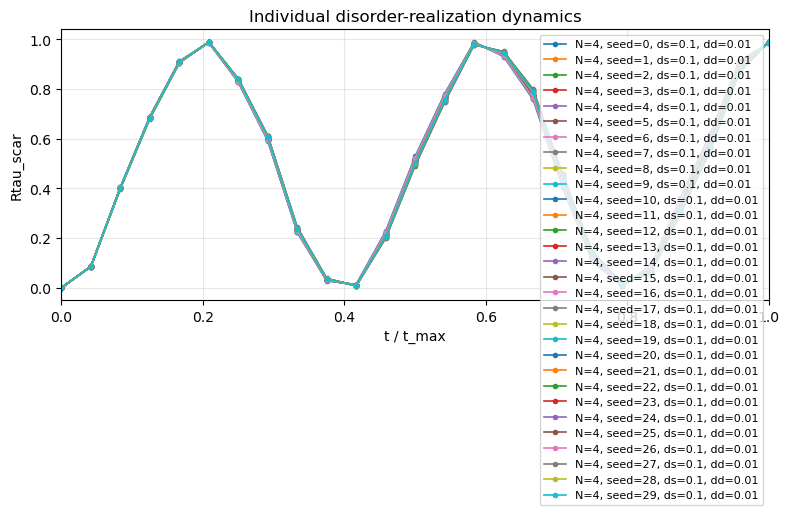

In [56]:
# Raw physics plot from individual disorder files
RAW_PHYSICS_FILTERS = {"N": EXPECTED_NLIST[0]}
MAX_RAW_CURVES = 30

raw_rows = filter_catalog(catalog, **RAW_PHYSICS_FILTERS)
raw_rows = to_table(raw_rows, SORT_COLUMNS)
raw_rows = raw_rows if isinstance(raw_rows, list) else raw_rows.to_dict("records")

print(f"Raw physics files matching {RAW_PHYSICS_FILTERS}: {len(raw_rows)}")

if not raw_rows:
    print("No files match the raw physics filters yet")
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))

    for row in raw_rows[:MAX_RAW_CURVES]:
        run = load_result(row["path"])
        normalized_time = run["tlist"] / float(run["t_max"])
        label = (
            f"N={row['N']}, seed={row['seed']}, "
            f"ds={row['ds']:g}, dd={row['dd']:g}"
        )
        ax.plot(
            normalized_time,
            run["Rtau_scar"],
            marker="o",
            markersize=3,
            linewidth=1.2,
            label=label,
        )

    ax.set_xlabel("t / t_max")
    ax.set_ylabel("Rtau_scar")
    ax.set_title("Individual disorder-realization dynamics")
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

In [57]:
# Inspect one selected file
SELECTED_FILTERS = {"N": EXPECTED_NLIST[0]}

selected_rows = filter_catalog(catalog, **SELECTED_FILTERS)
selected_row = selected_rows[0] if selected_rows else (catalog[0] if catalog else None)

if selected_row is None:
    selected_run = None
    print("No result files are available to inspect")
else:
    selected_run = load_result(selected_row["path"])
    saved_keys = [key for key in selected_run.keys() if key not in {"path", "filename"}]

    print(selected_run["filename"])
    print(f"saved keys: {', '.join(saved_keys)}")
    print(f"tlist shape: {selected_run['tlist'].shape}")
    print(f"Rtau_scar shape: {selected_run['Rtau_scar'].shape}")
    if "calculation_time_seconds" in selected_run:
        print(f"calculation_time_seconds: {float(selected_run['calculation_time_seconds']):.6f}")

selected_run

Rtau_N4_x0p0010_y0p0010_z0p0010_ds0p1000_dd0p0100_seed0_tmax157.07963267948963.npz
saved keys: seed, tlist, Rtau_scar, N, wd, x, y, z, ds, dd, calculation_time_seconds, t_max
tlist shape: (25,)
Rtau_scar shape: (25,)
calculation_time_seconds: 0.016758


{'seed': 0,
 'tlist': array([  0.        ,   6.54498469,  13.08996939,  19.63495408,
         26.17993878,  32.72492347,  39.26990817,  45.81489286,
         52.35987756,  58.90486225,  65.44984695,  71.99483164,
         78.53981634,  85.08480103,  91.62978573,  98.17477042,
        104.71975512, 111.26473981, 117.80972451, 124.3547092 ,
        130.8996939 , 137.44467859, 143.98966329, 150.53464798,
        157.07963268]),
 'Rtau_scar': array([0.        , 0.08641323, 0.40504411, 0.68931477, 0.91181966,
        0.98683314, 0.82790341, 0.5911069 , 0.22289649, 0.02767968,
        0.01274394, 0.22797835, 0.52896145, 0.78081666, 0.9885109 ,
        0.93090778, 0.75797047, 0.40398491, 0.10960714, 0.00668953,
        0.0897855 , 0.36169852, 0.61755631, 0.91280126, 0.98544522]),
 'N': 4,
 'wd': 0.6365091993031,
 'x': 0.001,
 'y': 0.001,
 'z': 0.001,
 'ds': 0.1,
 'dd': 0.01,
 'calculation_time_seconds': 0.01675845899444539,
 't_max': 157.07963267948963,
 'path': PosixPath('/Users/shemian29/Li

In [58]:
# Average Rtau_scar over disorder seeds for each parameter point
groups_by_parameters = defaultdict(list)
for row in catalog:
    key = tuple(row[column] for column in NON_SEED_PARAMETERS)
    groups_by_parameters[key].append(row)

seed_averaged_runs = []

for key, rows in sorted(groups_by_parameters.items()):
    runs = [load_result(row["path"]) for row in rows]
    reference_tlist = runs[0]["tlist"]
    reference_tmax = float(runs[0]["t_max"])

    if not all(np.allclose(reference_tlist, run["tlist"]) for run in runs):
        raise ValueError(f"Cannot average seeds with different time grids for {key}")
    if not all(np.isclose(reference_tmax, float(run["t_max"])) for run in runs):
        raise ValueError(f"Cannot average seeds with different t_max values for {key}")

    rtau_values = np.stack([run["Rtau_scar"] for run in runs])
    timing_values = np.array(
        [float(run["calculation_time_seconds"]) for run in runs if "calculation_time_seconds" in run],
        dtype=float,
    )

    seed_averaged_run = {column: value for column, value in zip(NON_SEED_PARAMETERS, key)}
    seed_averaged_run["seed_count"] = len(runs)
    seed_averaged_run["seeds"] = sorted(int(run["seed"]) for run in runs)
    seed_averaged_run["t_max"] = reference_tmax
    seed_averaged_run["tlist"] = reference_tlist
    seed_averaged_run["tlist_normalized"] = reference_tlist / reference_tmax
    seed_averaged_run["Rtau_scar_mean"] = rtau_values.mean(axis=0)
    seed_averaged_run["Rtau_scar_std"] = rtau_values.std(axis=0, ddof=1) if len(runs) > 1 else np.zeros_like(reference_tlist)
    seed_averaged_run["calculation_time_seconds_sum"] = float(timing_values.sum()) if timing_values.size else np.nan
    seed_averaged_run["calculation_time_seconds_mean"] = float(timing_values.mean()) if timing_values.size else np.nan
    seed_averaged_run["calculation_time_seconds_std"] = float(timing_values.std(ddof=1)) if timing_values.size > 1 else 0.0
    seed_averaged_runs.append(seed_averaged_run)

seed_summary_rows = []
for run in seed_averaged_runs:
    seed_summary_rows.append({
        "N": run["N"],
        "x": run["x"],
        "y": run["y"],
        "z": run["z"],
        "ds": run["ds"],
        "dd": run["dd"],
        "seed_count": run["seed_count"],
        "seeds": run["seeds"],
        "calculation_time_seconds_sum": run["calculation_time_seconds_sum"],
        "calculation_time_seconds_mean": run["calculation_time_seconds_mean"],
    })

seed_summary_table = to_table(seed_summary_rows, NON_SEED_PARAMETERS)
print(f"Built {len(seed_averaged_runs)} seed-averaged parameter groups")

if pd is None:
    display(seed_summary_table[:20])
else:
    display(seed_summary_table.head(20))

Built 1 seed-averaged parameter groups


,N,x,y,z,ds,dd,seed_count,seeds,calculation_time_seconds_sum,calculation_time_seconds_mean
0,4,0.001,0.001,0.001,0.1,0.01,40,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.353553,0.008839


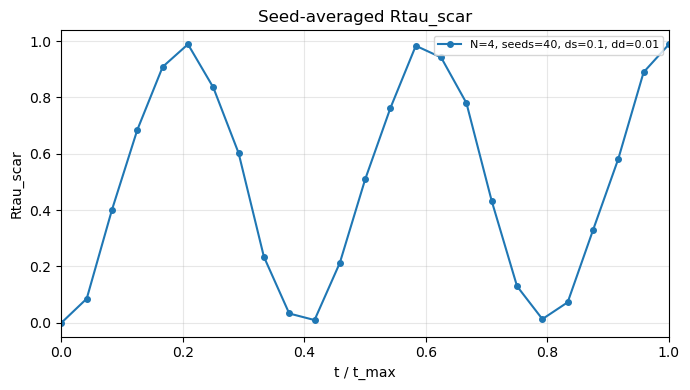

In [59]:
# Seed-averaged physics plots
PHYSICS_PARAMETERS = ["x", "y", "z", "ds", "dd"]
MAX_FALLBACK_AVERAGED_CURVES = 20


def format_parameter_value(value) -> str:
    if isinstance(value, (float, np.floating)):
        return f"{float(value):g}"
    return str(value)


plots_made = 0

for system_size in sorted({run["N"] for run in seed_averaged_runs}):
    runs_for_size = [run for run in seed_averaged_runs if run["N"] == system_size]
    parameter_values = {
        column: sorted({run[column] for run in runs_for_size})
        for column in PHYSICS_PARAMETERS
    }
    baseline_parameters = {
        column: values[0]
        for column, values in parameter_values.items()
        if values
    }

    for plot_parameter in PHYSICS_PARAMETERS:
        if len(parameter_values[plot_parameter]) <= 1:
            continue

        fixed_parameters = {
            column: value
            for column, value in baseline_parameters.items()
            if column != plot_parameter
        }
        selected_runs = [
            run
            for run in runs_for_size
            if all(values_match(run[column], value) for column, value in fixed_parameters.items())
        ]
        selected_runs = sorted(selected_runs, key=lambda run: run[plot_parameter])

        if not selected_runs:
            continue

        fig, ax = plt.subplots(figsize=(7, 4))
        for run in selected_runs:
            label = f"{plot_parameter}={format_parameter_value(run[plot_parameter])}"
            ax.plot(
                run["tlist_normalized"],
                run["Rtau_scar_mean"],
                marker="o",
                markersize=4,
                linewidth=1.5,
                label=label,
            )

            if run["seed_count"] > 1:
                lower = run["Rtau_scar_mean"] - run["Rtau_scar_std"]
                upper = run["Rtau_scar_mean"] + run["Rtau_scar_std"]
                ax.fill_between(run["tlist_normalized"], lower, upper, alpha=0.15)

        fixed_text = ", ".join(
            f"{column}={format_parameter_value(value)}"
            for column, value in fixed_parameters.items()
        )
        ax.set_title(f"N={system_size}: seed-averaged Rtau_scar varying {plot_parameter}\n{fixed_text}")
        ax.set_xlabel("t / t_max")
        ax.set_ylabel("Rtau_scar")
        ax.set_xlim(0, 1)
        ax.legend(title=plot_parameter)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        plt.show()
        plots_made += 1

if plots_made == 0 and seed_averaged_runs:
    fig, ax = plt.subplots(figsize=(7, 4))
    for run in seed_averaged_runs[:MAX_FALLBACK_AVERAGED_CURVES]:
        label = (
            f"N={run['N']}, seeds={run['seed_count']}, "
            f"ds={run['ds']:g}, dd={run['dd']:g}"
        )
        ax.plot(
            run["tlist_normalized"],
            run["Rtau_scar_mean"],
            marker="o",
            markersize=4,
            linewidth=1.5,
            label=label,
        )

    ax.set_title("Seed-averaged Rtau_scar")
    ax.set_xlabel("t / t_max")
    ax.set_ylabel("Rtau_scar")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

,N,expected_files,observed_files,timed_files,completion_fraction,recorded_time_seconds,full_sweep_time_seconds,projected_full_sweep_time_seconds
0,4,5400,40,40,0.007407,0.353553,NaN,47.729706
1,6,5400,0,0,0.000000,0.000000,NaN,NaN
2,8,5400,0,0,0.000000,0.000000,NaN,NaN


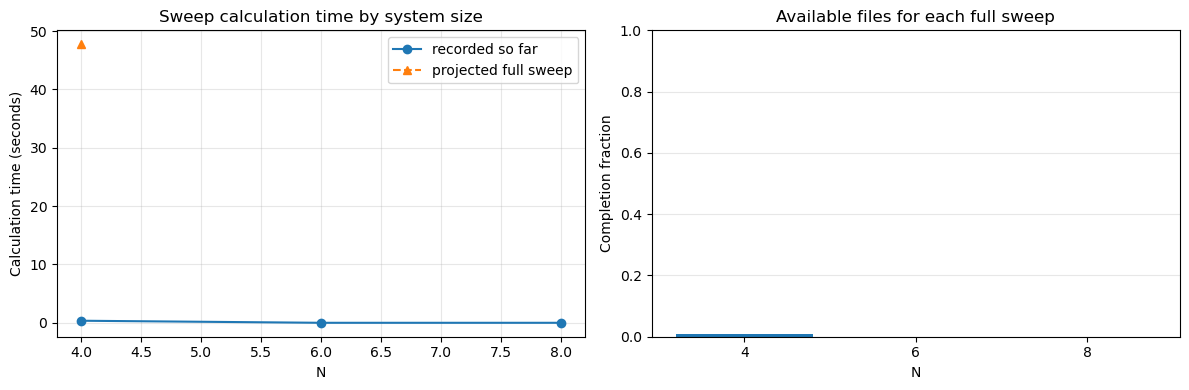

In [60]:
# Full-sweep calculation time scaling by system size
scaling_rows = []

for system_size in EXPECTED_NLIST:
    summaries_for_size = [summary for summary in file_summaries if summary["N"] == system_size]
    timed_summaries = [
        summary for summary in summaries_for_size
        if np.isfinite(summary["calculation_time_seconds"])
    ]

    expected_files = EXPECTED_FILES_PER_N
    observed_files = len(summaries_for_size)
    timed_files = len(timed_summaries)
    recorded_time_seconds = float(sum(summary["calculation_time_seconds"] for summary in timed_summaries))
    completion_fraction = observed_files / expected_files if expected_files else np.nan
    full_sweep_time_seconds = recorded_time_seconds if observed_files == expected_files else np.nan
    projected_full_sweep_time_seconds = (
        recorded_time_seconds / completion_fraction
        if completion_fraction and completion_fraction > 0.0
        else np.nan
    )

    scaling_rows.append({
        "N": system_size,
        "expected_files": expected_files,
        "observed_files": observed_files,
        "timed_files": timed_files,
        "completion_fraction": completion_fraction,
        "recorded_time_seconds": recorded_time_seconds,
        "full_sweep_time_seconds": full_sweep_time_seconds,
        "projected_full_sweep_time_seconds": projected_full_sweep_time_seconds,
    })

scaling_table = to_table(scaling_rows, ["N"])

if pd is None:
    display(scaling_table)
    plot_rows = scaling_table
else:
    display(scaling_table)
    plot_rows = scaling_table.to_dict("records")

plot_system_sizes = np.array([row["N"] for row in plot_rows], dtype=int)
recorded_times = np.array([row["recorded_time_seconds"] for row in plot_rows], dtype=float)
full_times = np.array([row["full_sweep_time_seconds"] for row in plot_rows], dtype=float)
projected_times = np.array([row["projected_full_sweep_time_seconds"] for row in plot_rows], dtype=float)
completion_fractions = np.array([row["completion_fraction"] for row in plot_rows], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    plot_system_sizes,
    recorded_times,
    marker="o",
    linewidth=1.5,
    label="recorded so far",
)

if np.any(np.isfinite(full_times)):
    axes[0].plot(
        plot_system_sizes,
        full_times,
        marker="s",
        linewidth=1.5,
        label="completed full sweep",
    )

if np.any(np.isfinite(projected_times)):
    axes[0].plot(
        plot_system_sizes,
        projected_times,
        marker="^",
        linewidth=1.5,
        linestyle="--",
        label="projected full sweep",
    )

axes[0].set_xlabel("N")
axes[0].set_ylabel("Calculation time (seconds)")
axes[0].set_title("Sweep calculation time by system size")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].bar(plot_system_sizes.astype(str), completion_fractions)
axes[1].set_xlabel("N")
axes[1].set_ylabel("Completion fraction")
axes[1].set_ylim(0, 1)
axes[1].set_title("Available files for each full sweep")
axes[1].grid(True, axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

In [61]:
# Local launch sizing for the current script configuration
CPUS_PER_TASK = 8
array_task_count = int(np.ceil(EXPECTED_TOTAL_FILES / CPUS_PER_TASK))
last_array_task_id = array_task_count - 1

launch_summary = {
    "expected_total_files": EXPECTED_TOTAL_FILES,
    "CPUS_PER_TASK": CPUS_PER_TASK,
    "array_task_count": array_task_count,
    "array_task_id_range": f"0 to {last_array_task_id}",
    "example_single_chunk_command": f"SLURM_ARRAY_TASK_ID=0 SLURM_CPUS_PER_TASK={CPUS_PER_TASK} conda run -n qdragon python main_local.py",
}

launch_summary

{'expected_total_files': 16200,
 'CPUS_PER_TASK': 8,
 'array_task_count': 2025,
 'array_task_id_range': '0 to 2024',
 'example_single_chunk_command': 'SLURM_ARRAY_TASK_ID=0 SLURM_CPUS_PER_TASK=8 conda run -n qdragon python main_local.py'}